# Data Exploration

## Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
from tqdm import tqdm
import logging

logging.basicConfig(filename="errores_slices.log", level=logging.WARNING)
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
%matplotlib inline

## Settings

In [2]:
!tree .. -d -L 2

..
├── Backups
├── Drive_and_Act
│   ├── a_column_co_driver
│   ├── a_column_driver
│   ├── activities_3s
│   ├── ceiling
│   ├── DataSet
│   ├── inner_mirror
│   ├── interior_3d
│   ├── kinect_color
│   ├── kinect_depth
│   ├── kinect_ir
│   ├── openpose_3d
│   └── steering_wheel
├── Notebooks
└── State_Farm
    └── state-farm-distracted-driver-detection

18 directories


In [3]:
!ls  ../Drive_and_Act/activities_3s/kinect_color/.

midlevel.chunks_90.csv
midlevel.chunks_90.split_0.test.csv
midlevel.chunks_90.split_0.train.csv
midlevel.chunks_90.split_0.val.csv
midlevel.chunks_90.split_1.test.csv
midlevel.chunks_90.split_1.train.csv
midlevel.chunks_90.split_1.val.csv
midlevel.chunks_90.split_2.test.csv
midlevel.chunks_90.split_2.train.csv
midlevel.chunks_90.split_2.val.csv
objectlevel.chunks_90.csv
objectlevel.chunks_90.split_0.test.csv
objectlevel.chunks_90.split_0.train.csv
objectlevel.chunks_90.split_0.val.csv
objectlevel.chunks_90.split_1.test.csv
objectlevel.chunks_90.split_1.train.csv
objectlevel.chunks_90.split_1.val.csv
objectlevel.chunks_90.split_2.test.csv
objectlevel.chunks_90.split_2.train.csv
objectlevel.chunks_90.split_2.val.csv
tasklevel.chunks_90.csv
tasklevel.chunks_90.split_0.test.csv
tasklevel.chunks_90.split_0.train.csv
tasklevel.chunks_90.split_0.val.csv
tasklevel.chunks_90.split_1.test.csv
tasklevel.chunks_90.split_1.train.csv
tasklevel.chunks_90.split_1.val.csv
tasklevel.chunks_90.split_2.te

In [4]:
# Define global folder paths
data_root = "../Drive_and_Act"
activities = f"{data_root}/activities_3s"
kinect_color = f"{data_root}/kinect_color"
kinect_ir = f"{data_root}/kinect_ir"
# Output folders for sliced frames
slices_output = f"{data_root}/kinect_color_slices/kinect_color_slices"
slices_ir_output = f"{data_root}/kinect_ir_slices/kinect_ir_slices"
output = f"{data_root}/DataSet"


In [5]:
# Constants
procesing = "Procesando videos"

## Data loading

In [6]:
midlevel = pd.read_csv(f"{activities}/kinect_color/midlevel.chunks_90.csv")
tasklevel = pd.read_csv(f"{activities}/kinect_color/tasklevel.chunks_90.csv")
objectlevel = pd.read_csv(f"{activities}/kinect_color/objectlevel.chunks_90.csv")

midlevel

,participant_id,file_id,annotation_id,frame_start,frame_end,activity,chunk_id
0,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,0,40,58,standing_by_the_door,0
1,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,1,58,82,closing_door_outside,0
2,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,2,83,102,standing_by_the_door,0
3,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,3,102,130,opening_door_outside,0
4,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,4,130,156,entering_car,0
...,...,...,...,...,...,...,...
10328,15,vp15/run2_2018-05-30-13-34-33.kinect_color,125,19595,19604,unfastening_seat_belt,1
10329,15,vp15/run2_2018-05-30-13-34-33.kinect_color,126,19604,19635,opening_door_inside,0
10330,15,vp15/run2_2018-05-30-13-34-33.kinect_color,127,19635,19680,exiting_car,0
10331,15,vp15/run2_2018-05-30-13-34-33.kinect_color,127,19680,19702,exiting_car,1


In [7]:
tasklevel 

,participant_id,file_id,annotation_id,frame_start,frame_end,activity,chunk_id
0,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,0,0,44,fasten_seat_belt,0
1,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,0,44,89,fasten_seat_belt,1
2,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,0,89,134,fasten_seat_belt,2
3,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,0,134,180,fasten_seat_belt,3
4,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,0,180,226,fasten_seat_belt,4
...,...,...,...,...,...,...,...
8474,15,vp15/run2_2018-05-30-13-34-33.kinect_color,11,19518,19563,final_task,6
8475,15,vp15/run2_2018-05-30-13-34-33.kinect_color,11,19563,19609,final_task,7
8476,15,vp15/run2_2018-05-30-13-34-33.kinect_color,11,19609,19655,final_task,8
8477,15,vp15/run2_2018-05-30-13-34-33.kinect_color,11,19655,19700,final_task,9


In [8]:
objectlevel

,participant_id,file_id,annotation_id,frame_start,frame_end,activity,object,location,chunk_id
0,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,0,175,188,reaching_for,seatbelt,left_backseat,0
1,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,1,189,208,retracting_from,seatbelt,left_backseat,0
2,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,2,208,230,interacting,seatbelt,no_location,0
3,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,3,240,258,reaching_for,multimedia_display,center_console_front,0
4,1,vp1/run1b_2018-05-29-14-02-47.kinect_color,4,3011,3031,reaching_for,automation_button,center_console_back,0
...,...,...,...,...,...,...,...,...,...
9964,15,vp15/run2_2018-05-30-13-34-33.kinect_color,177,19375,19388,retracting_from,no_object,no_location,0
9965,15,vp15/run2_2018-05-30-13-34-33.kinect_color,178,19550,19571,reaching_for,no_object,no_location,0
9966,15,vp15/run2_2018-05-30-13-34-33.kinect_color,179,19571,19576,interacting,no_object,no_location,0
9967,15,vp15/run2_2018-05-30-13-34-33.kinect_color,180,19576,19596,placing_moving_to,no_object,no_location,0


In [9]:
midlevel.describe()

,participant_id,annotation_id,frame_start,frame_end,chunk_id
count,10333.000000,10333.000000,10333.000000,10333.000000,10333.000000
mean,7.918707,58.665247,12445.068712,12483.195974,5.032227
std,4.410855,33.693124,6102.086781,6102.638909,7.988657
min,1.000000,0.000000,6.000000,32.000000,0.000000
25%,4.000000,30.000000,7583.000000,7619.000000,0.000000
50%,8.000000,57.000000,12098.000000,12131.000000,2.000000
75%,12.000000,83.000000,16735.000000,16767.000000,6.000000
max,15.000000,148.000000,33230.000000,33252.000000,66.000000


In [10]:
midlevel.activity.describe()

count             10333
unique               39
top       sitting_still
freq               2797
Name: activity, dtype: object

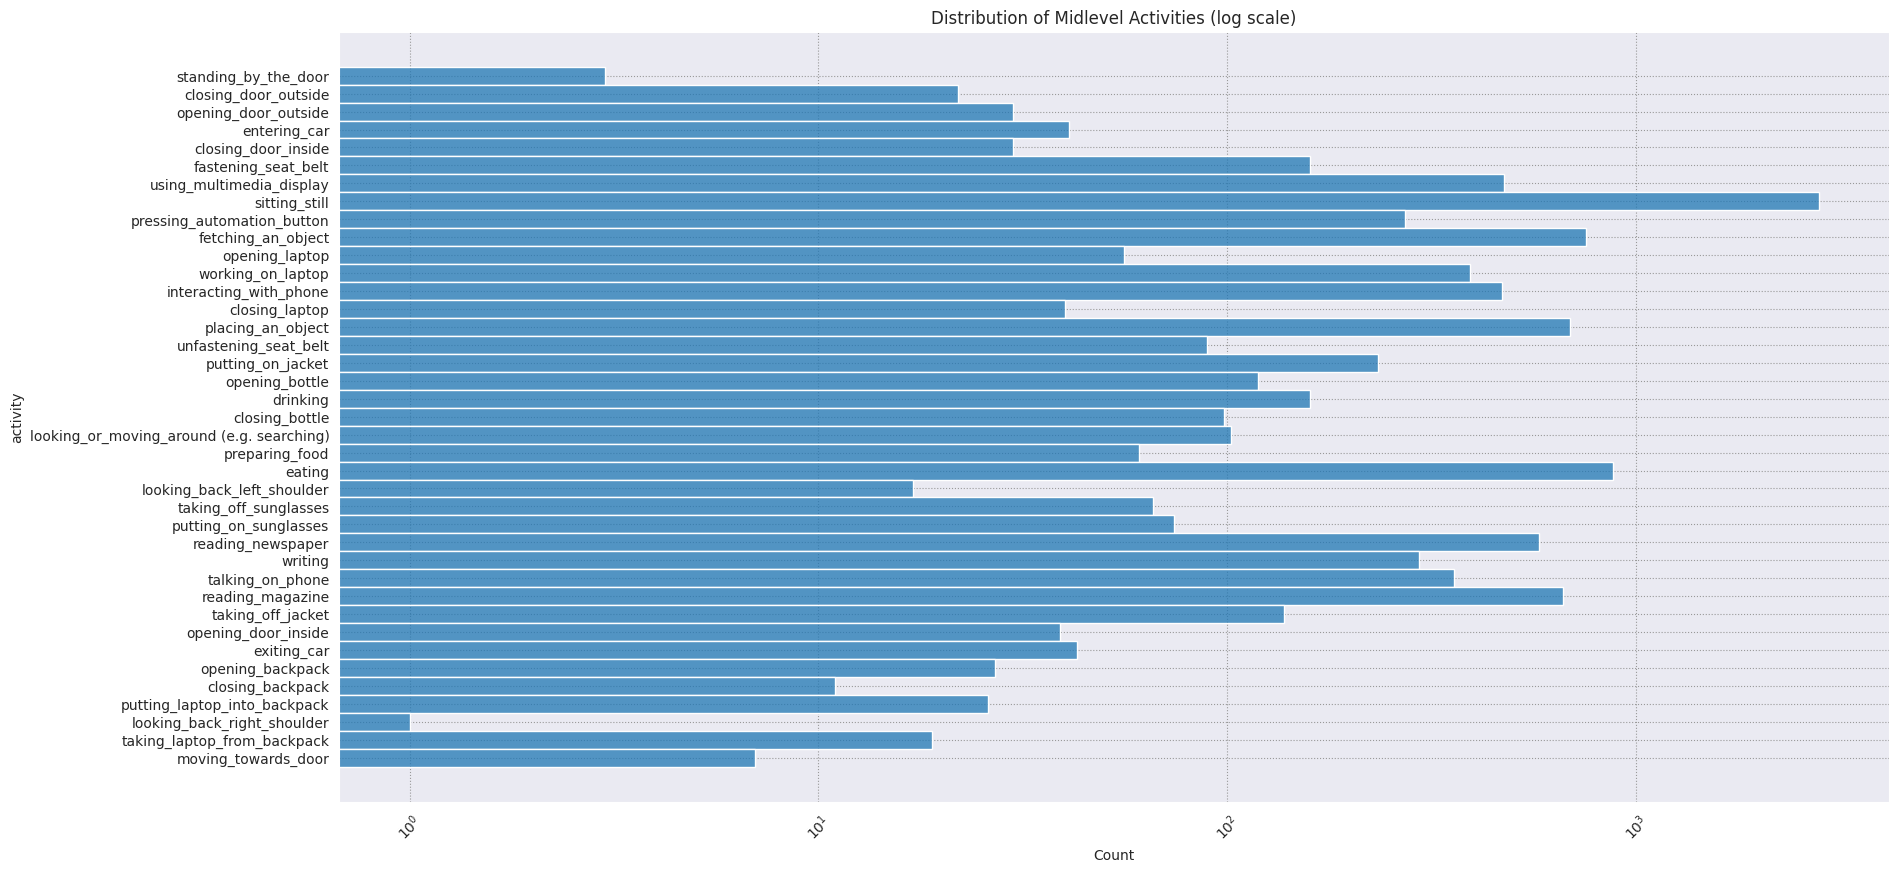

In [11]:
plt.figure(figsize=(20,10))
sns.histplot(y=midlevel.activity,)
plt.xticks(rotation=45);
plt.xscale('log')
plt.title("Distribution of Midlevel Activities (log scale)");

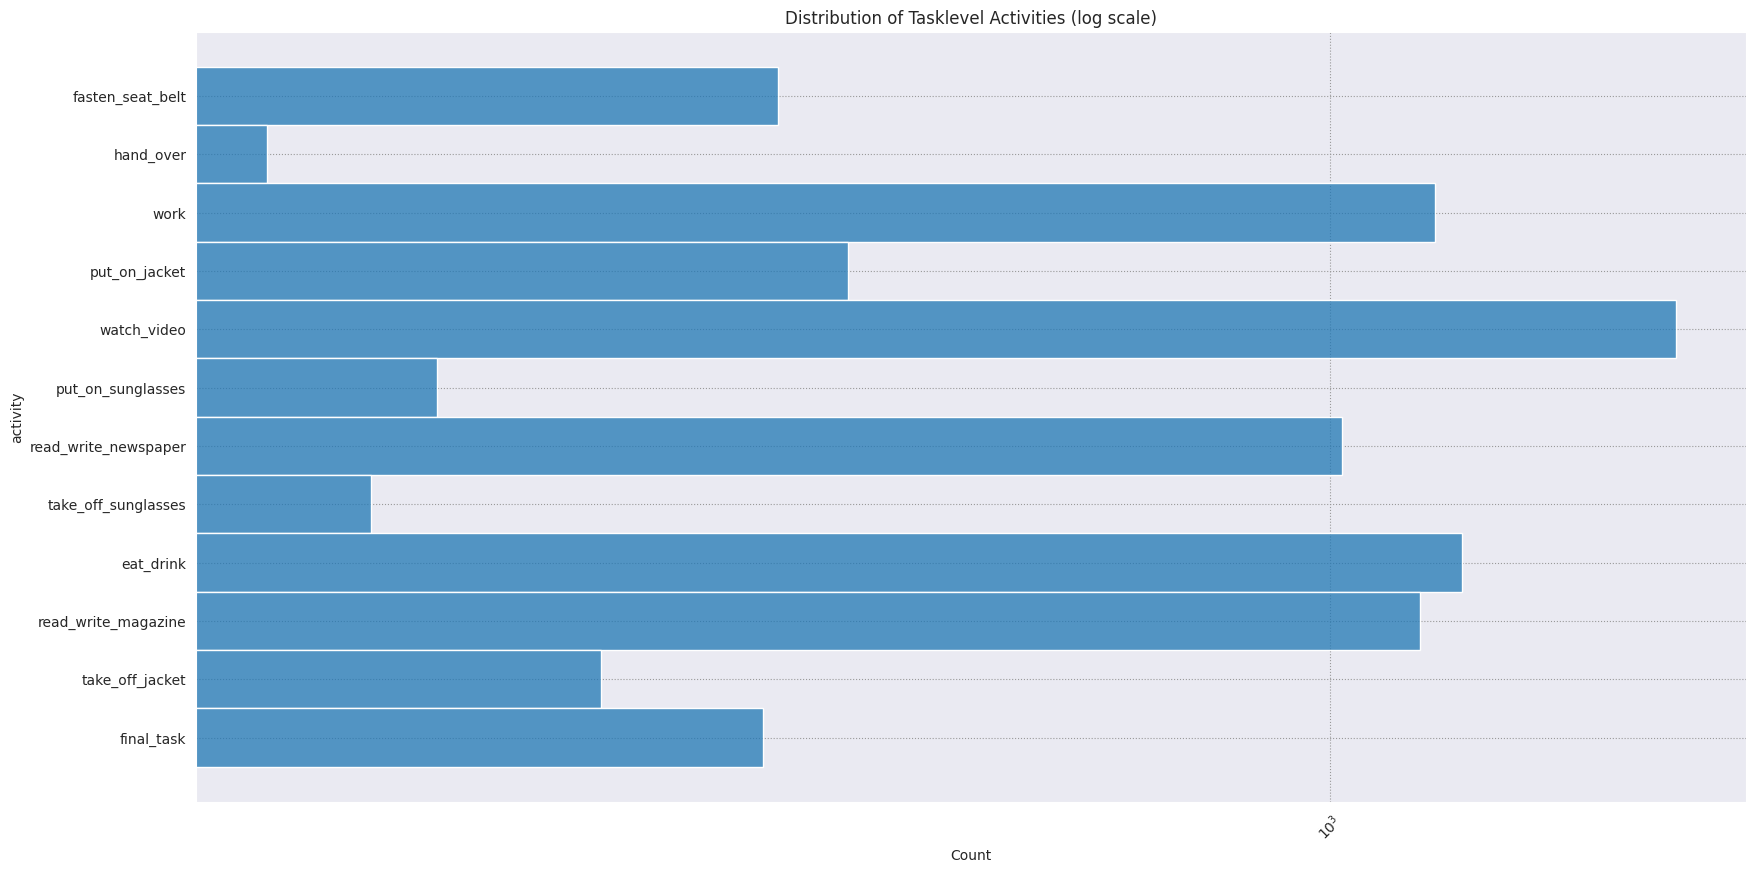

In [12]:
plt.figure(figsize=(20,10))
sns.histplot(y=tasklevel.activity,)
plt.xticks(rotation=45);
plt.xscale('log')
plt.title("Distribution of Tasklevel Activities (log scale)");

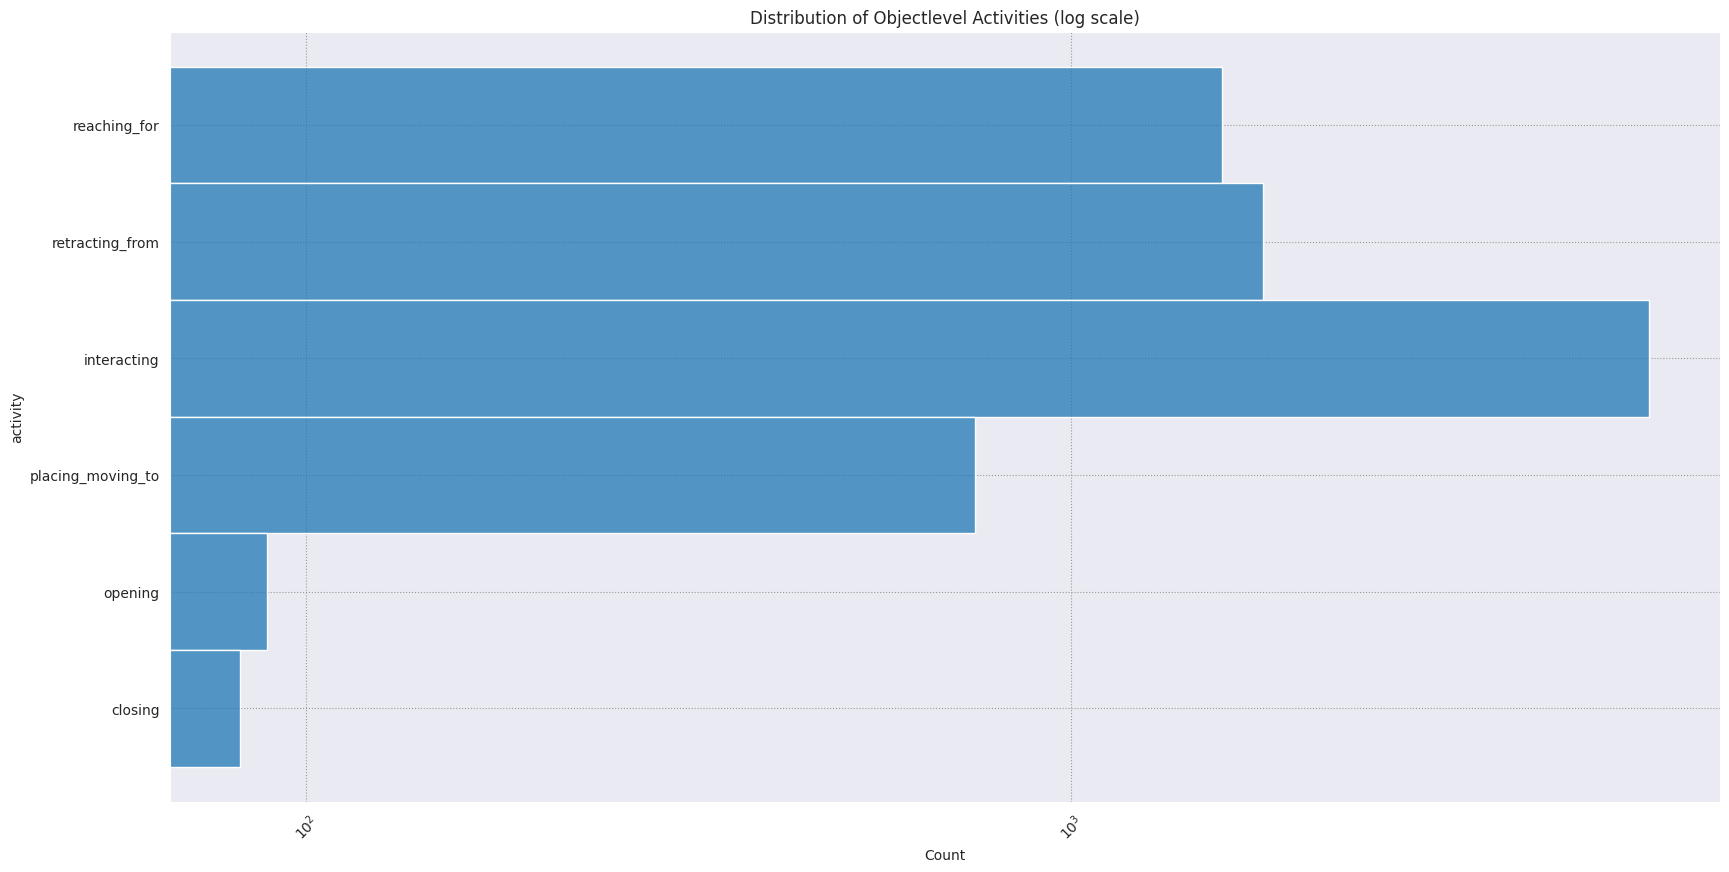

In [13]:
plt.figure(figsize=(20,10))
sns.histplot(y=objectlevel.activity,)
plt.xticks(rotation=45);
plt.xscale('log')
plt.title("Distribution of Objectlevel Activities (log scale)");

In [14]:
for act in np.unique(midlevel.activity):
    print(act)

closing_backpack
closing_bottle
closing_door_inside
closing_door_outside
closing_laptop
drinking
eating
entering_car
exiting_car
fastening_seat_belt
fetching_an_object
interacting_with_phone
looking_back_left_shoulder
looking_back_right_shoulder
looking_or_moving_around (e.g. searching)
moving_towards_door
opening_backpack
opening_bottle
opening_door_inside
opening_door_outside
opening_laptop
placing_an_object
preparing_food
pressing_automation_button
putting_laptop_into_backpack
putting_on_jacket
putting_on_sunglasses
reading_magazine
reading_newspaper
sitting_still
standing_by_the_door
taking_laptop_from_backpack
taking_off_jacket
taking_off_sunglasses
talking_on_phone
unfastening_seat_belt
using_multimedia_display
working_on_laptop
writing


In [15]:
sample = midlevel.query("activity == 'eating'").iloc[0]
sample

participant_id                                             1
file_id           vp1/run1b_2018-05-29-14-02-47.kinect_color
annotation_id                                             50
frame_start                                             7627
frame_end                                               7672
activity                                              eating
chunk_id                                                   0
Name: 118, dtype: object

In [16]:
midlevel.activity.unique()

array(['standing_by_the_door', 'closing_door_outside',
       'opening_door_outside', 'entering_car', 'closing_door_inside',
       'fastening_seat_belt', 'using_multimedia_display', 'sitting_still',
       'pressing_automation_button', 'fetching_an_object',
       'opening_laptop', 'working_on_laptop', 'interacting_with_phone',
       'closing_laptop', 'placing_an_object', 'unfastening_seat_belt',
       'putting_on_jacket', 'opening_bottle', 'drinking',
       'closing_bottle', 'looking_or_moving_around (e.g. searching)',
       'preparing_food', 'eating', 'looking_back_left_shoulder',
       'taking_off_sunglasses', 'putting_on_sunglasses',
       'reading_newspaper', 'writing', 'talking_on_phone',
       'reading_magazine', 'taking_off_jacket', 'opening_door_inside',
       'exiting_car', 'opening_backpack', 'closing_backpack',
       'putting_laptop_into_backpack', 'looking_back_right_shoulder',
       'taking_laptop_from_backpack', 'moving_towards_door'], dtype=object)

In [17]:
tasklevel.activity.unique()

array(['fasten_seat_belt', 'hand_over', 'work', 'put_on_jacket',
       'watch_video', 'put_on_sunglasses', 'read_write_newspaper',
       'take_off_sunglasses', 'eat_drink', 'read_write_magazine',
       'take_off_jacket', 'final_task'], dtype=object)

In [18]:
objectlevel.activity.unique()

array(['reaching_for', 'retracting_from', 'interacting',
       'placing_moving_to', 'opening', 'closing'], dtype=object)

In [19]:
objectlevel.describe()

,participant_id,annotation_id,frame_start,frame_end,chunk_id
count,9969.000000,9969.000000,9969.000000,9969.000000,9969.000000
mean,8.040024,99.777510,12171.467048,12201.164811,3.433945
std,4.353568,58.602692,6035.620106,6035.919981,7.172020
min,1.000000,0.000000,26.000000,45.000000,0.000000
25%,4.000000,51.000000,7406.000000,7443.000000,0.000000
50%,8.000000,97.000000,11941.000000,11961.000000,0.000000
75%,12.000000,146.000000,16306.000000,16330.000000,4.000000
max,15.000000,296.000000,33085.000000,33096.000000,66.000000


In [20]:
# Obtener los conjuntos de actividades
midlevel_acts = set(midlevel.activity.unique())
tasklevel_acts = set(tasklevel.activity.unique())

# Encontrar intersecciones
common_activities = midlevel_acts.intersection(tasklevel_acts)

print("Actividades que aparecen en ambos niveles:")
if len(common_activities) > 0:
    for act in sorted(common_activities):
        print(f"- {act}")
else:
    print("No hay actividades que se repitan entre midlevel y tasklevel")

print("\nActividades únicas en midlevel:")
only_midlevel = midlevel_acts - tasklevel_acts
for act in sorted(only_midlevel):
    print(f"- {act}")

print("\nActividades únicas en tasklevel:")
only_tasklevel = tasklevel_acts - midlevel_acts
for act in sorted(only_tasklevel):
    print(f"- {act}")

Actividades que aparecen en ambos niveles:
No hay actividades que se repitan entre midlevel y tasklevel

Actividades únicas en midlevel:
- closing_backpack
- closing_bottle
- closing_door_inside
- closing_door_outside
- closing_laptop
- drinking
- eating
- entering_car
- exiting_car
- fastening_seat_belt
- fetching_an_object
- interacting_with_phone
- looking_back_left_shoulder
- looking_back_right_shoulder
- looking_or_moving_around (e.g. searching)
- moving_towards_door
- opening_backpack
- opening_bottle
- opening_door_inside
- opening_door_outside
- opening_laptop
- placing_an_object
- preparing_food
- pressing_automation_button
- putting_laptop_into_backpack
- putting_on_jacket
- putting_on_sunglasses
- reading_magazine
- reading_newspaper
- sitting_still
- standing_by_the_door
- taking_laptop_from_backpack
- taking_off_jacket
- taking_off_sunglasses
- talking_on_phone
- unfastening_seat_belt
- using_multimedia_display
- working_on_laptop
- writing

Actividades únicas en tasklevel

In [21]:
# Obtener los conjuntos de actividades
midlevel_acts = set(midlevel.activity.unique())
objectlevel_acts = set(objectlevel.activity.unique())

# Encontrar intersecciones
common_activities = midlevel_acts.intersection(tasklevel_acts)

print("Actividades que aparecen en ambos niveles:")
if len(common_activities) > 0:
    for act in sorted(common_activities):
        print(f"- {act}")
else:
    print("No hay actividades que se repitan entre midlevel y tasklevel")

print("\nActividades únicas en midlevel:")
only_midlevel = midlevel_acts - objectlevel_acts
for act in sorted(only_midlevel):
    print(f"- {act}")

print("\nActividades únicas en tasklevel:")
only_tasklevel = objectlevel_acts - midlevel_acts
for act in sorted(only_tasklevel):
    print(f"- {act}")

Actividades que aparecen en ambos niveles:
No hay actividades que se repitan entre midlevel y tasklevel

Actividades únicas en midlevel:
- closing_backpack
- closing_bottle
- closing_door_inside
- closing_door_outside
- closing_laptop
- drinking
- eating
- entering_car
- exiting_car
- fastening_seat_belt
- fetching_an_object
- interacting_with_phone
- looking_back_left_shoulder
- looking_back_right_shoulder
- looking_or_moving_around (e.g. searching)
- moving_towards_door
- opening_backpack
- opening_bottle
- opening_door_inside
- opening_door_outside
- opening_laptop
- placing_an_object
- preparing_food
- pressing_automation_button
- putting_laptop_into_backpack
- putting_on_jacket
- putting_on_sunglasses
- reading_magazine
- reading_newspaper
- sitting_still
- standing_by_the_door
- taking_laptop_from_backpack
- taking_off_jacket
- taking_off_sunglasses
- talking_on_phone
- unfastening_seat_belt
- using_multimedia_display
- working_on_laptop
- writing

Actividades únicas en tasklevel

In [22]:
midlevel_ir = pd.read_csv(f"{activities}/kinect_ir/midlevel.chunks_90.csv")
tasklevel_ir = pd.read_csv(f"{activities}/kinect_ir/tasklevel.chunks_90.csv")
objectlevel_ir = pd.read_csv(f"{activities}/kinect_ir/objectlevel.chunks_90.csv")

In [23]:
def slice_frame(folder, video_folder, sample_dict) -> None:
    """Crea un video slice desde frame_start hasta frame_end."""
    try:
        start_frame = int(sample_dict["frame_start"])
        end_frame = int(sample_dict["frame_end"])
        file_id = str(sample_dict["file_id"])
        annotation_id = str(sample_dict["annotation_id"])
        chunk_id = str(sample_dict["chunk_id"])
        participant_id = str(sample_dict["participant_id"])

        video_path = f"{video_folder}/{file_id}.mp4"
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
           logging.warning(f"❌ Error abriendo video: {video_path}")

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        start_frame = max(0, start_frame)
        end_frame = min(end_frame, total_frames - 1)
        if start_frame > end_frame:
            cap.release()
            logging.warning(f"⚠️ Rango inválido: {file_id}")

        out_path = f"{folder}/{file_id.replace('/', '_')}_id_{annotation_id}_chunk_{chunk_id}_participant_{participant_id}.mp4"
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(out_path, fourcc, fps, (w, h))

        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        cur = start_frame
        while cur <= end_frame:
            ret, frame = cap.read()
            if not ret:
                break
            out.write(frame)
            cur += 1

        cap.release()
        out.release()
    
    except Exception as e:
        logging.warning(f"{sample_dict['file_id']}: {e}")

In [24]:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_dataframe_parallel(df, output_folder, video_folder, max_workers=6) -> None:
    """Procesa todos los samples en paralelo."""
    samples = df[["file_id", "annotation_id", "frame_start", "frame_end","chunk_id","participant_id"]].to_dict(orient="records")
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(slice_frame, output_folder, video_folder, sample): sample
            for sample in samples
             
        }

        for _ in tqdm(as_completed(futures), total=len(futures), desc="Procesando"):
            continue

# Paralel Data Aquisition

In [25]:
process_dataframe_parallel(midlevel, slices_output+"_midlevel", kinect_color, max_workers=10)


Procesando: 100%|██████████| 10333/10333 [19:26<00:00,  8.86it/s]


In [26]:
process_dataframe_parallel(tasklevel, slices_output+"_tasklevel", kinect_color, max_workers=10)

Procesando: 100%|██████████| 8479/8479 [22:30<00:00,  6.28it/s]


In [27]:
process_dataframe_parallel(objectlevel, slices_output+"_objectlevel", kinect_color, max_workers=10)

Procesando: 100%|██████████| 9969/9969 [24:47<00:00,  6.70it/s]


In [25]:
process_dataframe_parallel(midlevel_ir, slices_ir_output+"_midlevel", kinect_ir, max_workers=10)

Procesando: 100%|██████████| 10333/10333 [05:42<00:00, 30.18it/s]


In [26]:
process_dataframe_parallel(tasklevel_ir, slices_ir_output+"_tasklevel", kinect_ir, max_workers=6)

Procesando: 100%|██████████| 8479/8479 [04:53<00:00, 28.90it/s]


In [27]:
process_dataframe_parallel(objectlevel_ir, slices_ir_output+"_objectlevel", kinect_ir, max_workers=6)

Procesando: 100%|██████████| 9969/9969 [04:24<00:00, 37.73it/s]


In [26]:
import os
modals = os.listdir('../Drive_and_Act/')
del modals[modals.index('kinect_color')]
del modals[modals.index('kinect_ir')]
del modals[modals.index('activities_3s')]
del modals[modals.index('DataSet')]
del modals[modals.index('openpose_3d')]
modals

['steering_wheel',
 'a_column_driver',
 'kinect_depth',
 'inner_mirror',
 'interior_3d',
 '.directory',
 'a_column_co_driver',
 'ceiling']

In [27]:
for modal in modals:
    os.makedirs( output+f"/{modal}", exist_ok=True)
os.listdir(output)

['steering_wheel',
 'a_column_driver',
 'kinect_depth',
 'kinect_color',
 'inner_mirror',
 'interior_3d',
 '.directory',
 'kinect_ir',
 'a_column_co_driver',
 'ceiling',
 'openpose_3d']

In [33]:
for modal in modals:

    print('Processing modal:', modal)
    folder = output+f"/{modal}"
    os.makedirs( output+f"/{modal}/midlevel", exist_ok=True)
    os.makedirs( output+f"/{modal}/tasklevel", exist_ok=True)
    os.makedirs( output+f"/{modal}/objectlevel", exist_ok=True)

    print('midlevel processing...')
    df = pd.read_csv(f"{activities}/{modal}/midlevel.chunks_90.csv")
    process_dataframe_parallel(df, folder+"/midlevel", f"{data_root}/{modal}", max_workers=10)

    print('tasklevel processing...')
    df = pd.read_csv(f"{activities}/{modal}/tasklevel.chunks_90.csv")
    process_dataframe_parallel(df, folder+"/tasklevel", f"{data_root}/{modal}", max_workers=10)
    
    print('objectlevel processing...')
    df = pd.read_csv(f"{activities}/{modal}/objectlevel.chunks_90.csv")
    process_dataframe_parallel(df, folder+"/objectlevel", f"{data_root}/{modal}", max_workers=10)

Processing modal: a_column_co_driver
midlevel processing...


Procesando: 100%|██████████| 10333/10333 [45:08<00:00,  3.82it/s] 

tasklevel processing...



Procesando: 100%|██████████| 8479/8479 [41:08<00:00,  3.44it/s] 


objectlevel processing...


...

Procesando: 100%|██████████| 10333/10333 [38:57<00:00,  4.42it/s] 

tasklevel processing...



Procesando: 100%|██████████| 8479/8479 [30:15<00:00,  4.67it/s]


objectlevel processing...


Procesando: 100%|██████████| 9969/9969 [27:47<00:00,  5.98it/s]
